# DOS Plotting for g-BC3

## Electronic density versus energy

In the file `SUMMARY.fcc`

+ The 1st column: lattice parameter (in Å units)
+ The 2nd column: unit number (always 1 in this case)
+ The 3rd column: free energy (in eV units)
+ The 4th column: initial energy (in eV units)
+ The 5th column: energy change (difference between initial and current energy, in eV units)

In [4]:
# Import the necessary packages
import xml.etree.ElementTree as ET

# Analysis vasprun.xml file
tree = ET.parse('1_Lattice_Relaxation_accurate/vasprun.xml')
root = tree.getroot()

# Extract Fermi energy
efermi = float(root.find(".//i[@name='efermi']").text)

# Extract Energies Total DOS Integrated DOS
energies_list, energies_shift, total_dos_list, integrated_dos_list = [], [], [], []

for r_element in root.findall(".//set[@comment='spin 1']/r"):
    values = list(map(float, r_element.text.split()))
    energies = values[0]
    energies_list.append(energies)
    total_dos = values[1]
    total_dos_list.append(total_dos)
    integrated_dos = values[2]
    integrated_dos_list.append(integrated_dos)

# Shift process
shift = efermi; energies_shift = [var - shift for var in energies_list]

print (efermi)
# print (energies_list)
# print (energies_shift)


-2.85549221


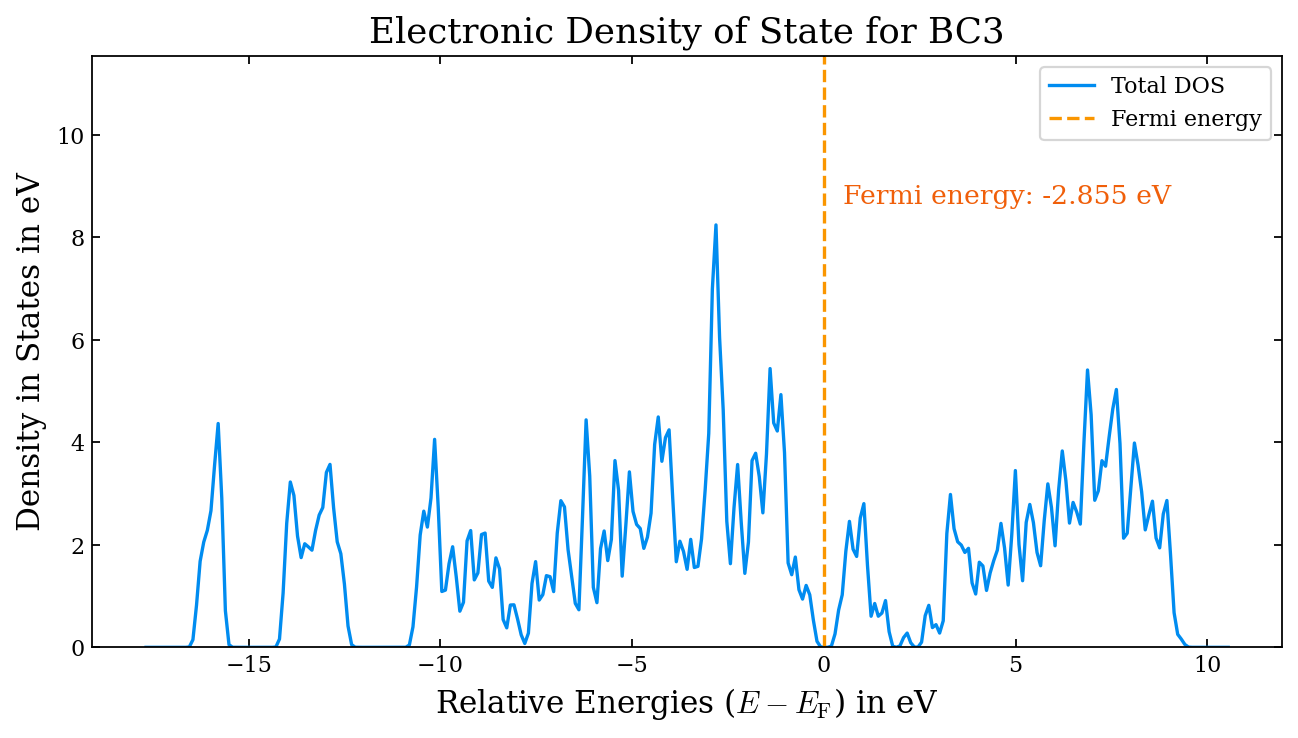

In [5]:
# Import the necessary packages
import matplotlib.pyplot as plt

# Set up the specified style parameters
plt.figure(dpi=160, figsize=(9.6,4.8))
params = {"text.usetex": False, "font.family": "serif", "mathtext.fontset": "cm", "axes.titlesize": 16, "axes.labelsize": 14, "figure.facecolor": "w"}
plt.rcParams.update(params)
plt.tick_params(direction="in", which="both", top=True, right=True, bottom=True, left=True)

plt.title("Electronic Density of State for BC3"); plt.xlabel(r"Relative Energies ($E-E_\mathrm{F}$) in eV"); plt.ylabel(r"Density in States in eV")

plt.plot(energies_shift, total_dos_list, c="#008CF0", label="Total DOS"); y_axis_top = max(total_dos_list)
# plt.plot(energies_shift, integrated_dos_list, c="#8C64F0", label="Integrated DOS"); y_axis_top = max(max(total_dos_list), max(integrated_dos_list))

# Plot Fermi energy as a vertical line
plt.axvline(x=efermi-shift, linestyle="--", color="#FA9600", label="Fermi energy")

# Add Fermi energy value to the plot
fermi_energy_text = f"Fermi energy: {efermi:.3f} eV"
plt.text(efermi-shift+0.5, y_axis_top*1.05, fermi_energy_text, fontsize=12, color="#F05F0A", rotation=0)

plt.ylim(0, y_axis_top*1.4)
plt.legend(loc="best")
plt.show()

## Bandstructure

The band structure is demonstrated with Energy (in eV) versus K-point distance (in Å).

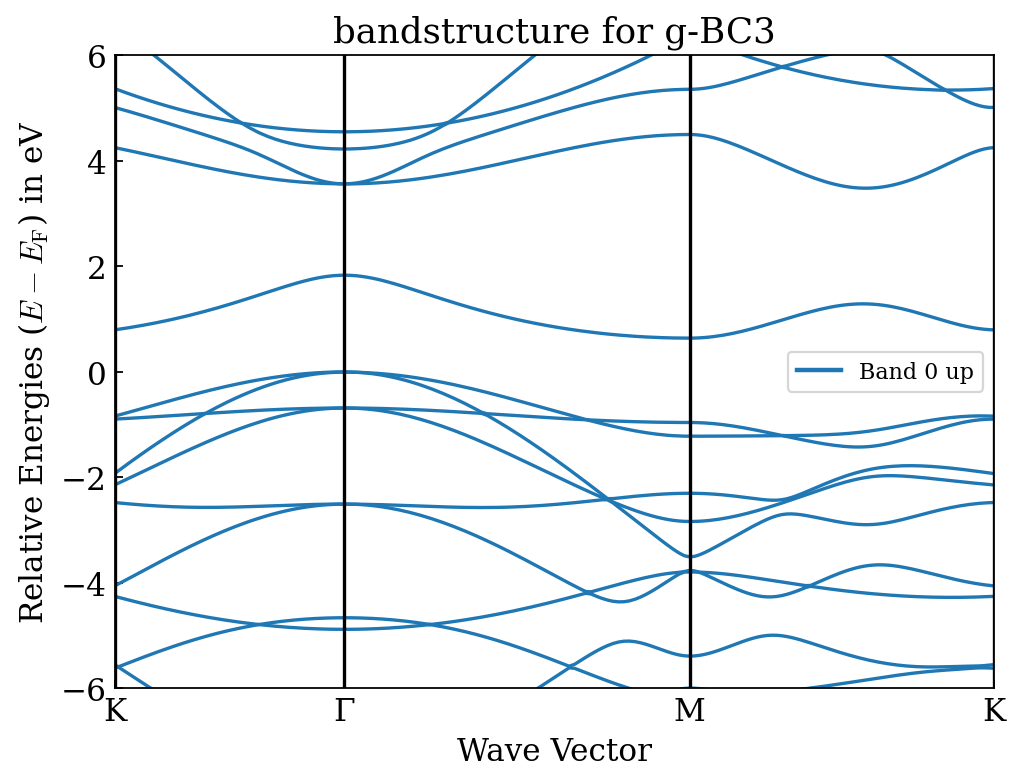

In [7]:
# Plot 2D matter bandstructure
import matplotlib.pyplot as plt
from pymatgen.electronic_structure.plotter import BSPlotter
from pymatgen.io.vasp import Vasprun
from pymatgen.io.vasp.inputs import Kpoints

vasp_run = Vasprun("3_Bandstructure_beta/vasprun.xml", parse_potcar_file=False)
kpoints_file = "3_Bandstructure_beta/KPOINTS"
kpoints = Kpoints.from_file(kpoints_file)

bandstructure = vasp_run.get_band_structure(kpoints_filename=kpoints_file, line_mode=True)

plotter = BSPlotter(bandstructure)
plot_data = plotter.bs_plot_data()

# Plot

params = {"text.usetex": False, "font.family": "serif", "mathtext.fontset": "cm", "axes.titlesize": 16, "axes.labelsize": 14, "figure.facecolor": "w"}
plt.rcParams.update(params)

plotter.get_plot(ylim=(-6, 6))

ax = plt.gca()
ax.figure.set_dpi(160)
ax.figure.set_size_inches(6.4,4.8)

ax.set_title("bandstructure for g-BC3",fontsize=params['axes.titlesize'])
ax.set_xlabel(r"Wave Vector", fontsize=params['axes.labelsize'])
ax.set_ylabel(r"Relative Energies ($E-E_\mathrm{F}$) in eV", fontsize=params['axes.labelsize'])
ax.tick_params(axis='both', labelsize=params['axes.labelsize'],direction='in')

